In [5]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

# Define the exact path to your CSV file
file_path = r"C:\Users\Irene\OneDrive\churn_data.csv"

# Read the data from the CSV file into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows of the fetched data
print(data.head())

   11098-MAD  Female  30  Yes  Madhya Pradesh   0  31  Deal 1 Yes.1   No  ...  \
0  11114-PUN    Male  51   No          Punjab   5   9  Deal 5   Yes   No  ...   
1  11167-WES  Female  43  Yes     West Bengal   3  28  Deal 1   Yes  Yes  ...   
2  11179-MAH    Male  35   No     Maharashtra  10  12     NaN   Yes   No  ...   
3  11180-TAM    Male  75  Yes      Tamil Nadu  12  27  Deal 2   Yes   No  ...   
4  11241-MAD  Female  41  Yes  Madhya Pradesh   4  11     NaN   Yes   No  ...   

   Bank Withdrawal 95.0999984741211 6683.39990234375    0.1  0.2  \
0  Bank Withdrawal        49.150002       169.050003   0.00   10   
1  Bank Withdrawal       116.050003      8297.500000  42.57  110   
2      Credit Card        84.400002      5969.299805   0.00    0   
3      Credit Card        72.599998      4084.350098   0.00  140   
4  Bank Withdrawal       105.099998      3634.800049   0.00    0   

  631.719970703125 7315.1201171875   Stayed      Others  \
0       122.370003      301.420013  Churned  

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. Load the data directly from the perfectly formatted EXCEL file
file_path = r"C:\Users\Irene\OneDrive\churn_data 1.xlsx"
data = pd.read_excel(file_path)

# Clean headers just in case
data.columns = data.columns.str.strip()

# 2. Drop explicitly known useless columns (ignores if spelled differently)
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1, errors='ignore')

# 3. Manually encode the target variable 'Customer_Status' FIRST
if 'Customer_Status' in data.columns:
    data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})
    data = data.dropna(subset=['Customer_Status'])

# 4. AUTO-CLEANER: Find ALL remaining text/string columns and handle them!
string_columns = data.select_dtypes(include=['object']).columns
for col in string_columns:
    # If the column has almost all unique values (like an ID), drop it.
    if data[col].nunique() > len(data) * 0.5:
        data = data.drop(col, axis=1)
        print(f"-> Dropped '{col}' automatically (looks like an ID column).")
    else:
        # Otherwise, it is a category. Encode it to numbers.
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        print(f"-> Encoded '{col}' automatically.")

# 5. Split data into features (X) and target (y)
X = data.drop('Customer_Status', axis=1, errors='ignore')
y = data['Customer_Status']

# 6. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 8. Make predictions and print the evaluation
y_pred = rf_model.predict(X_test)

print("\n" + "="*30)
print("--- MODEL EVALUATION ---")
print("="*30)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

-> Dropped 'Customer_Id' automatically (looks like an ID column).
-> Encoded 'Gender' automatically.
-> Encoded 'Married' automatically.
-> Encoded 'State' automatically.
-> Encoded 'Value_Deal' automatically.
-> Encoded 'Phone_Service' automatically.
-> Encoded 'Multiple_Lines' automatically.
-> Encoded 'Internet_Service' automatically.
-> Encoded 'Internet_Type' automatically.
-> Encoded 'Online_Security' automatically.
-> Encoded 'Online_Backup' automatically.
-> Encoded 'Device_Protection_Plan' automatically.
-> Encoded 'Premium_Support' automatically.
-> Encoded 'Streaming_TV' automatically.
-> Encoded 'Streaming_Movies' automatically.
-> Encoded 'Streaming_Music' automatically.
-> Encoded 'Unlimited_Data' automatically.
-> Encoded 'Contract' automatically.
-> Encoded 'Paperless_Billing' automatically.
-> Encoded 'Payment_Method' automatically.

--- MODEL EVALUATION ---

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.92

Confusion Matrix:
[[12  1]
 [ 2  4]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.92      0.89        13
         1.0       0.80      0.67      0.73         6

    accuracy                           0.84        19
   macro avg       0.83      0.79      0.81        19
weighted avg       0.84      0.84      0.84        19



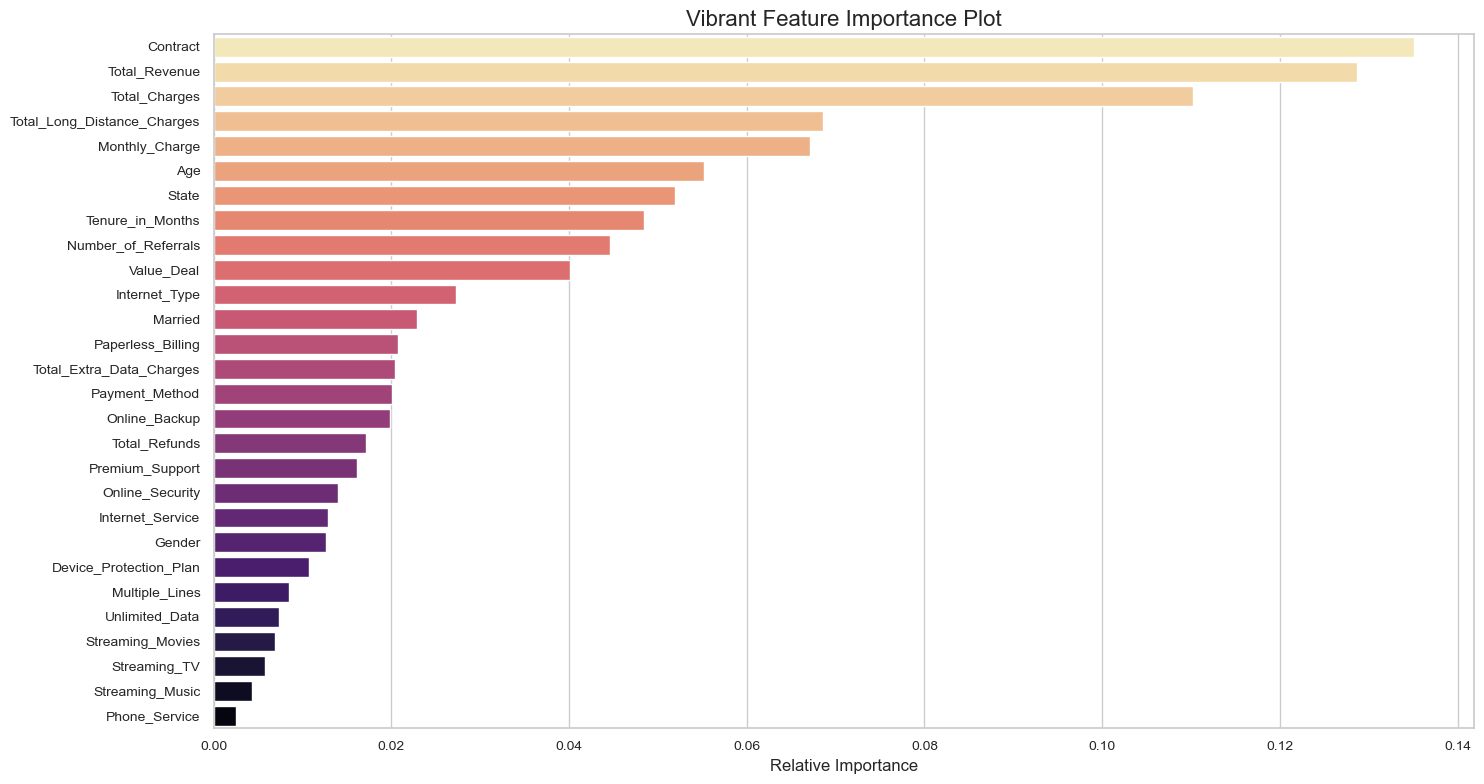

In [25]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# # Evaluate Model <--- FIXED SYNTAX ERROR HERE BY ADDING #
# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]


# --- STYLED VIBRANT FEATURE IMPORTANCE PLOT ---
import pandas as pd  # Added pandas import for cleaner plotting

# Set figure size and cleaner theme
plt.figure(figsize=(15, 8)) # increased height for clarity
sns.set_theme(style="whitegrid") # clean white grid theme

# Create a temporary dataframe for robust colorful plotting
# We keep the sorted features and importances
feat_imp_df = pd.DataFrame({
    'Feature Name': X.columns[indices],
    'Relative Importance': importances[indices]
})

# Plot using Seaborn barplot
# Assigning Feature Name to 'hue' creates a colorful bar for each sorted feature.
# 'palette="magma_r"' gives a progressive purple to pink to red multi-color gradient look.
ax = sns.barplot(
    data=feat_imp_df,
    x='Relative Importance',
    y='Feature Name',
    hue='Feature Name', # Color each bar individually
    palette='magma_r',  # progressive multi-color palette
    orient='h',         # horizontal orientation
    legend=False        # turn off legend
)

# Style labels and title
plt.title('Vibrant Feature Importance Plot', fontsize=16)
plt.xlabel('Relative Importance', fontsize=12)
# The y-label is Redundant, clear from feature names
plt.ylabel('', fontsize=12)
plt.tick_params(axis='y', labelsize=10)
plt.tick_params(axis='x', labelsize=10)

plt.tight_layout() # ensures labels don't get cut off
plt.show()

In [28]:
import pandas as pd

# 1. Define the exact path to your new Customer Data file
file_path = r"C:\Users\Irene\Downloads\Data-Resources\Data & Resources\Data\Customer_Data.csv"

# 2. Read the data into a pandas DataFrame
new_data = pd.read_csv(file_path)

# Clean the headers just to be safe
new_data.columns = new_data.columns.str.strip()

print("Successfully loaded new customer data. First 5 rows:")
# THIS IS THE LINE THAT PRINTS YOUR SCREENSHOT OUTPUT:
print(new_data.head())
print("\n" + "-" * 50)

# 3. Retain the original DataFrame to preserve unencoded columns for our final report
original_data = new_data.copy()

# 4. Drop columns that won't be used for prediction
columns_to_drop = ['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason']
new_data = new_data.drop(columns_to_drop, axis=1, errors='ignore')

# 5. Encode categorical variables with a SAFETY NET for unseen labels
for column in new_data.select_dtypes(include=['object']).columns:
    if column in label_encoders:
        le = label_encoders[column]
        known_classes = set(le.classes_)
        
        # SAFETY NET: If a value (like 'Chhattisgarh') is not in the known classes, 
        # replace it temporarily with the first known class to prevent crashing.
        safe_data = new_data[column].astype(str).apply(
            lambda x: x if x in known_classes else le.classes_[0]
        )
        
        # Now transform the safe data
        new_data[column] = le.transform(safe_data)

# 6. Make predictions using your trained Random Forest model
print("Crystal ball activated! Predicting churn risks...")
new_predictions = rf_model.predict(new_data)

# 7. Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions

# 8. Filter to find ONLY the customers predicted to Churn (where prediction == 1)
churn_risks = original_data[original_data['Customer_Status_Predicted'] == 1]

# 9. Save the final list of "at-risk" customers to your Downloads folder
save_path = r"C:\Users\Irene\Downloads\Churn_Predictions_Report.csv"
churn_risks.to_csv(save_path, index=False)

print("\n" + "="*50)
print(f"SUCCESS! Out of the total new customers, the model identified {len(churn_risks)} at risk of churning.")
print(f"Your final prediction file has been saved to: {save_path}")
print("="*50)

Successfully loaded new customer data. First 5 rows:
  Customer_ID  Gender  Age Married        State  Number_of_Referrals  \
0   19877-DEL    Male   35      No        Delhi                    7   
1   58353-MAH  Female   45     Yes  Maharashtra                   14   
2   25063-WES    Male   51      No  West Bengal                    4   
3   59787-KAR    Male   79      No    Karnataka                    3   
4   28544-TAM  Female   80      No   Tamil Nadu                    3   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                27        NaN           Yes             No  ...   
1                13        NaN           Yes            Yes  ...   
2                35     Deal 5           Yes             No  ...   
3                21     Deal 4           Yes             No  ...   
4                 8        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0      Credit Card           65.6       